# **Optimización TP1**: Redes Neuronales

Para esta primera parte trabajaremos con el archivo utils_tools.jl, el
dataset Iris y seguiremos los lineamientos vistos aquí. Utilizaremos una red
con tres capas (con funciones de activación ReLu, identidad y softmax) de 5
niveles.

In [ ]:
using Pkg
Pkg.add(["LinearAlgebra", "RDatasets", "Random", "Statistics", "Plots"])

In [1]:
include("utils_tools.jl")
using LinearAlgebra, RDatasets, Random, Statistics, Plots

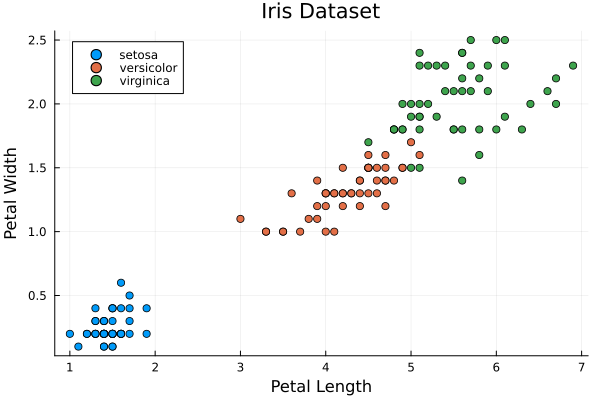

In [2]:
iris = dataset("datasets", "iris")
X = Matrix(iris[:, 1:4])
Y = iris.Species

scatter(iris.PetalLength, 
        iris.PetalWidth, 
        group=iris.Species, 
        xlabel="Petal Length", ylabel="Petal Width",
        title="Iris Dataset", legend=:topleft)

## **Ejercicios**: Aplicación del Método de Descenso por Gradiente

In [3]:
# Conjuntos de Train y Test
X_train, Y_train, X_test, Y_test, classes = prepare_data(X, Y, do_normal=true, do_onehot=true)

# Estrucutra de la red
mutable struct RedSimple{T<:Real}
    W1::Matrix{T}
    b1::Vector{T}
    W2::Matrix{T}
    b2::Vector{T}
    
end

In [20]:
Random.seed!(912)

W1 = randn(5, size(X_train, 1))  
b1 = randn(5)
W2 = randn(size(Y_train, 1), 5)
b2 = randn(size(Y_train, 1))

model = RedSimple(W1,b1,W2,b2)

RedSimple{Float64}([-0.2452268542676702 0.41143723675207616 2.4271021491834883 -0.19255903035754515; -1.187396401103834 0.4191810741495605 -0.7615652258668397 1.1494678759776331; … ; -0.6827994841403416 -2.0249805838950423 -1.0126751408123955 0.9145434803937996; 0.21015014894022765 -0.3458497309828835 -1.5365251275876872 0.6623853478171181], [1.289142128792834, -0.6537575972172397, 1.7535786845454593, 0.11407516226735083, -0.3346605437683106], [-0.59511633503199 1.0510277553155014 … -1.246587189804987 -0.3269086904197188; -0.05618298473414387 -0.2436298150908353 … -1.0901688802798823 0.6984578183898887; -1.6945631152471219 0.6037738105791013 … -1.682943439171012 0.06286363141176406], [0.7763516636706733, 1.5148972776132552, -0.20387003891877545])

### **Ejercicio 1**: Función `forward_pass`

In [5]:
# Funciones de activación
softmax(x) = exp.(x) / sum(exp.(x))
relu(x)    = max.(0, x)

relu (generic function with 1 method)

In [6]:
function forward_pass(model, x, layeroutput=false)
    # Array para backpropagation
    layerop = []

    # Layer 1: ReLu
    z1 = model.W1 * x + model.b1
    a1 = relu(z1)               
    push!(layerop, (z1, a1))

    # Layer 2: Identidad + Softmax
    z2 = model.W2 * a1 + model.b2
    a2 = softmax(z2)
    push!(layerop, (z2, a2))

    # Condicion para retorno
    return (layeroutput ? (a2, layerop) : a2)

end

forward_pass (generic function with 2 methods)

### **Ejercicio 2**: Función `grad`

In [7]:
function grad(model, x, y)
    # Predicción del modelo
    y_pred, layerop = forward_pass(model, x, true)
    z1, a1 = layerop[1]
    
    # Cálculo de gradientes
    δ2  = y_pred - y
    ∇W2 = δ2 * a1'
    ∇b2 = δ2

    δ1  = (model.W2' * δ2) .* float.(z1 .> 0) 
    ∇W1 = δ1 * x'
    ∇b1 = δ1
    
    return (∇W1, ∇b1, ∇W2, ∇b2)
    
end

grad (generic function with 1 method)

### **Ejercicio 3**: Función `train!`

In [8]:
function train!(model, X, Y, η, max_iter)
    # Vector de pérdidas
    losses = Vector{Float64}()

    # Iteraciones de entrenamiento
    for k in 1:max_iter
        # Loss
        loss = mean([-sum(Y[:,j] .* log.(forward_pass(model, X[:,j]))) for j in 1:size(X,2)])
        push!(losses, loss)
        
        # Gradiente
        ∇L = grad_total(model, grad, X, Y)
        
        # Actualización de parámetros
        model.W1 = model.W1 - η * ∇L[1]
        model.b1 = model.b1 - η * ∇L[2]
        model.W2 = model.W2 - η * ∇L[3]
        model.b2 = model.b2 - η * ∇L[4]

        # Criterio de parada
        if sum(norm.(∇L)) < 1e-6
            break
            
        end
    end
    return model, losses
    
end

train! (generic function with 1 method)

### **Ejercicio 4**: Función `results`

In [21]:
function results(model, X_train, Y_train, X_test, Y_test, losses)    
    # Gráfico de pérdida
    grafico = plot(losses, xlabel="Iteración", ylabel="Loss", title="Convergencia", legend=false)
    
    # Accuracy en train
    train_predicted = 0
    for j in 1:size(X_train, 2)
        y_pred = argmax(forward_pass(model, X_train[:,j]))
        y_real = argmax(Y_train[:,j])
        train_predicted += (y_pred == y_real)
        
    end
    acc_train = train_predicted / size(X_train, 2)
    
    # Accuracy en test
    test_predicted = 0
    for j in 1:size(X_test, 2)
        y_pred = argmax(forward_pass(model, X_test[:,j]))
        y_real = argmax(Y_test[:,j])
        test_predicted += (y_pred == y_real)
        
    end
    acc_test = test_predicted / size(X_test, 2)
    return grafico, acc_train, acc_test
    
end

results (generic function with 1 method)

## **Resultados**

In [22]:
# Definimos parámetros de entrenamiento
η = 0.05
max_iter = 10000

# Entrenamiento
@time model, losses = train!(model, X_train, Y_train, η, max_iter)

  2.133340 seconds (56.82 M allocations: 4.258 GiB, 18.07% gc time)


(RedSimple{Float64}([0.3768151185034044 0.048309769745957874 0.6700080320565235 -0.9475600598180354; -2.535426766886133 0.6087310445105037 -1.9753779829032607 0.07191107503068625; … ; -0.8752547083140354 -2.147461364497468 -1.378002540770224 0.5603066338871602; 0.25774796916994636 -0.48096285998600624 -1.4244953964966354 0.7811003158991318], [3.1358657932923846, 0.17414754387474432, -0.6780481332797214, 0.09350172559037112, -0.3420278499922763], [-1.3661515397972068 2.3217300681288635 … -1.8011091409218396 -0.2292987890943988; 0.9938193478558548 -1.5818879438186906 … -0.39263720298383475 0.7209791325224614; -1.9735302430718997 0.6713296264935992 … -1.8259531653502001 -0.05726758404613121], [0.767933586988948, 2.7726599875774904, -1.4532146722012687]), [5.051143628155907, 4.364390354949633, 3.722565925046615, 3.151559401838322, 2.6552272721649475, 2.2324149956739308, 1.8863626072016957, 1.6149708510946892, 1.40817541160186, 1.2532389822332126  …  0.041008325023476136, 0.0410077106989373

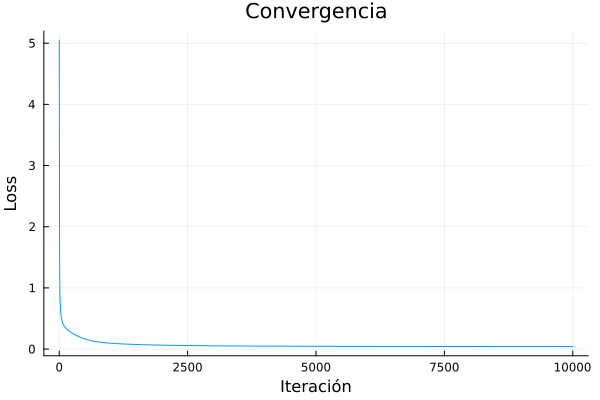

In [25]:
grafico, acc_train, acc_test = results(model, X_train, Y_train, X_test, Y_test, losses)
grafico

In [26]:
# Accuracy en train
println("Accuracy en TRAIN: ", acc_train)
# Accuracy en test
println("Accuracy en TEST: ", acc_test)

Accuracy en TRAIN: 0.9833333333333333
Accuracy en TEST: 1.0
